In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import  sklearn
from sklearn.model_selection import train_test_split
import ray
import os
import math
import matplotlib.pyplot as plt

2023-11-15 19:54:46.251051: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-15 19:54:46.398837: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-11-15 19:54:47.755702: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-11-15 19:54:47.755812: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or 

In [2]:
train_data = 'train_data.npy'
train_data_arr = np.load(train_data, allow_pickle=True)
len(train_data_arr[0])
len(train_data_arr[0]['images']) #344
len(train_data_arr[0]['labels']) #344


344

In [3]:
train_data_arr[0]['labels'][0]

40

In [4]:
test_data = 'test_data.npy'
test_data_arr = np.load(test_data, allow_pickle=True)

In [5]:
len(test_data_arr)

1

In [6]:
len(test_data_arr[0]['images'])

3621

# Step 1: Describe the data distribution among classes of the overall dataset and 5 users of your choice.

## All dataset

In [7]:
overalllabels = []
for i in range(100):
    for j in range (0, len(train_data_arr[i]['labels'])):
        overalllabels.append(train_data_arr[i]['labels'][j])

In [8]:
overalllabels_arr = np.array (overalllabels)

Class Distribution Table:
| Class | Count |
|-------|-------|
|     0 |   999 |
|     1 |  1094 |
|     2 |   904 |
|     3 |  1015 |
|     4 |   897 |
|     5 |   819 |
|     6 |   907 |
|     7 |   997 |
|     8 |   930 |
|     9 |   955 |
|    10 |   412 |
|    11 |   193 |
|    12 |   711 |
|    13 |   322 |
|    14 |   504 |
|    15 |   629 |
|    16 |    67 |
|    17 |   191 |
|    18 |   748 |
|    19 |   190 |
|    20 |    65 |
|    21 |   322 |
|    22 |   562 |
|    23 |   577 |
|    24 |  1837 |
|    25 |   555 |
|    26 |    75 |
|    27 |   410 |
|    28 |  1606 |
|    29 |   705 |
|    30 |   891 |
|    31 |   257 |
|    32 |   243 |
|    33 |    84 |
|    34 |   244 |
|    35 |    77 |
|    36 |   600 |
|    37 |   253 |
|    38 |    77 |
|    39 |   625 |
|    40 |  1680 |
|    41 |    78 |
|    42 |   165 |
|    43 |   519 |
|    44 |    94 |
|    45 |    56 |
|    46 |    79 |
|    47 |  1584 |
|    48 |    70 |
|    49 |   761 |
|    50 |    78 |
|    51 |    62 |
| 

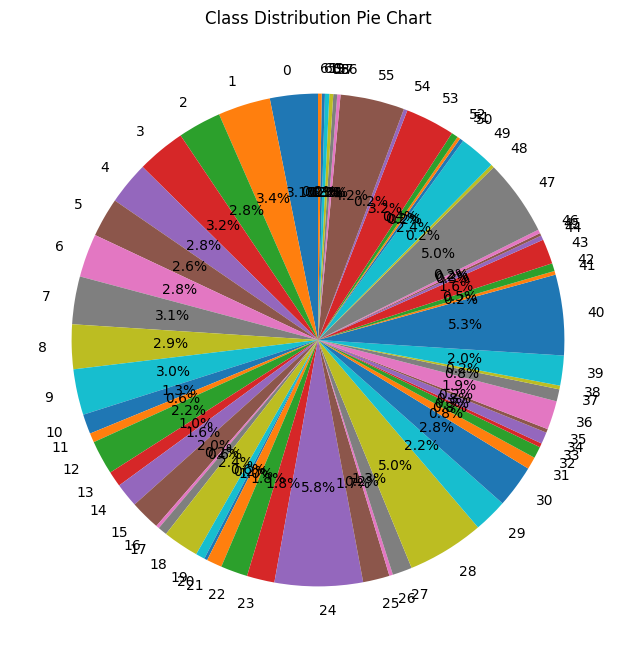

In [9]:


# Step 2: Table
unique_classes, class_counts = np.unique(overalllabels_arr , return_counts=True)
class_distribution_table = np.column_stack((unique_classes, class_counts))

print("Class Distribution Table:")
print("| Class | Count |")
print("|-------|-------|")
for row in class_distribution_table:
    print(f"| {int(row[0]):5d} | {int(row[1]):5d} |")

# Step 3: Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=unique_classes, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution Pie Chart')
plt.show()


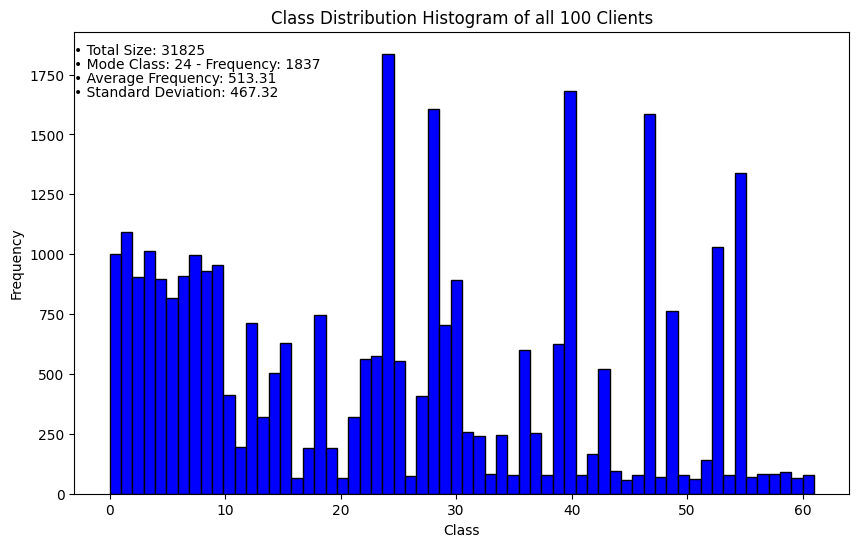

In [35]:

# Step 1: Histogram
'''
plt.figure(figsize=(10, 6))
plt.hist(overalllabels_arr , bins=62, color='skyblue', edgecolor='black')
plt.title('Class Distribution Histogram')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()
'''

# Example data
labels = overalllabels_arr 

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(labels, bins=62, color='blue', edgecolor='black')

# Calculate statistics
total_size = len(labels)
mode_class = np.bincount(labels).argmax()
mode_frequency = np.bincount(labels).max()
average_frequency = np.mean(np.bincount(labels))
std_dev_frequency = np.std(np.bincount(labels))

# Annotate the plot
plt.title('Class Distribution Histogram of all 100 Clients')
plt.xlabel('Class')
plt.ylabel('Frequency')
#plt.text(0.5, 0.8, f'Total Size: {total_size}', transform=plt.gca().transAxes)
#plt.text(0.5, 0.7, f'Mode Class: {mode_class}, Frequency: {mode_frequency}', transform=plt.gca().transAxes)
#plt.text(0.5, 0.6, f'Average Frequency: {average_frequency}', transform=plt.gca().transAxes)
#plt.text(0.5, 0.5, f'Standard Deviation: {std_dev_frequency}', transform=plt.gca().transAxes)


# Your previous code...

# Show legend at upper left with single spacing
'''
plt.legend([
    f'Total Size: {total_size}',
    f'Mode Class: {mode_class} - Frequency: {mode_frequency}',
    f'Average Frequency: {average_frequency}',
    f'Standard Deviation: {std_dev_frequency}'],loc='upper left', prop={'size': 10}, title='Statistics', title_fontsize='large',
    handlelength=1, handletextpad=1, borderpad=1)
'''
# Your previous code...

'''
plt.text(0.0, 0.95, f'Total Size: {total_size}', transform=plt.gca().transAxes)
plt.text(0.0, 0.92, f'Mode Class: {mode_class} - Frequency: {mode_frequency}', transform=plt.gca().transAxes)
plt.text(0.0, 0.89, f'Average Frequency: {average_frequency}', transform=plt.gca().transAxes)
plt.text(0.0, 0.86, f'Standard Deviation: {std_dev_frequency}', transform=plt.gca().transAxes)
'''
# Annotate the plot with condensed text and bullet points
plt.text(0.0, 0.95, f'\u2022 Total Size: {total_size:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.92, f'\u2022 Mode Class: {mode_class} - Frequency: {mode_frequency:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.89, f'\u2022 Average Frequency: {average_frequency:.2f}', transform=plt.gca().transAxes)
plt.text(0.0, 0.86, f'\u2022 Standard Deviation: {std_dev_frequency:.2f}', transform=plt.gca().transAxes)



plt.show()






## Random 5  users

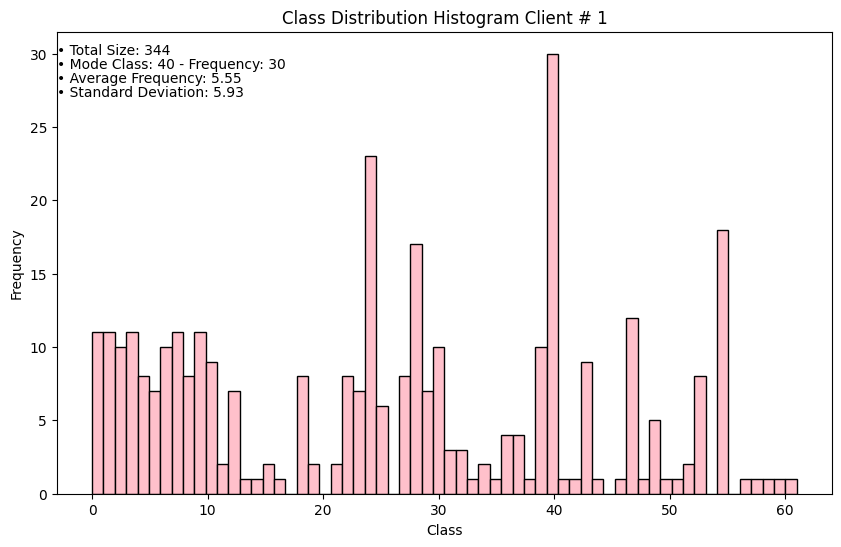

In [36]:
plt.figure(figsize=(10, 6))
labels = train_data_arr[0]['labels']
plt.hist(labels, bins=62, color='pink', edgecolor='black')

# Calculate statistics
total_size = len(labels)
mode_class = np.bincount(labels).argmax()
mode_frequency = np.bincount(labels).max()
average_frequency = np.mean(np.bincount(labels))
std_dev_frequency = np.std(np.bincount(labels))

# Annotate the plot
plt.title('Class Distribution Histogram Client # 1')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.text(0.0, 0.95, f'\u2022 Total Size: {total_size:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.92, f'\u2022 Mode Class: {mode_class} - Frequency: {mode_frequency:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.89, f'\u2022 Average Frequency: {average_frequency:.2f}', transform=plt.gca().transAxes)
plt.text(0.0, 0.86, f'\u2022 Standard Deviation: {std_dev_frequency:.2f}', transform=plt.gca().transAxes)



plt.show()


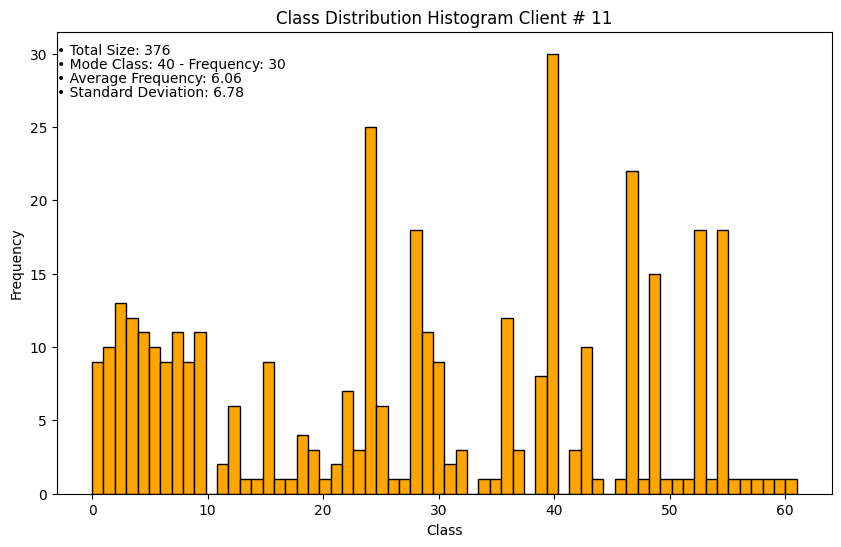

In [37]:
plt.figure(figsize=(10, 6))
labels = train_data_arr[10]['labels']
plt.hist(labels, bins=62, color='orange', edgecolor='black')

# Calculate statistics
total_size = len(labels)
mode_class = np.bincount(labels).argmax()
mode_frequency = np.bincount(labels).max()
average_frequency = np.mean(np.bincount(labels))
std_dev_frequency = np.std(np.bincount(labels))

# Annotate the plot
plt.title('Class Distribution Histogram Client # 11')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.text(0.0, 0.95, f'\u2022 Total Size: {total_size:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.92, f'\u2022 Mode Class: {mode_class} - Frequency: {mode_frequency:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.89, f'\u2022 Average Frequency: {average_frequency:.2f}', transform=plt.gca().transAxes)
plt.text(0.0, 0.86, f'\u2022 Standard Deviation: {std_dev_frequency:.2f}', transform=plt.gca().transAxes)



plt.show()

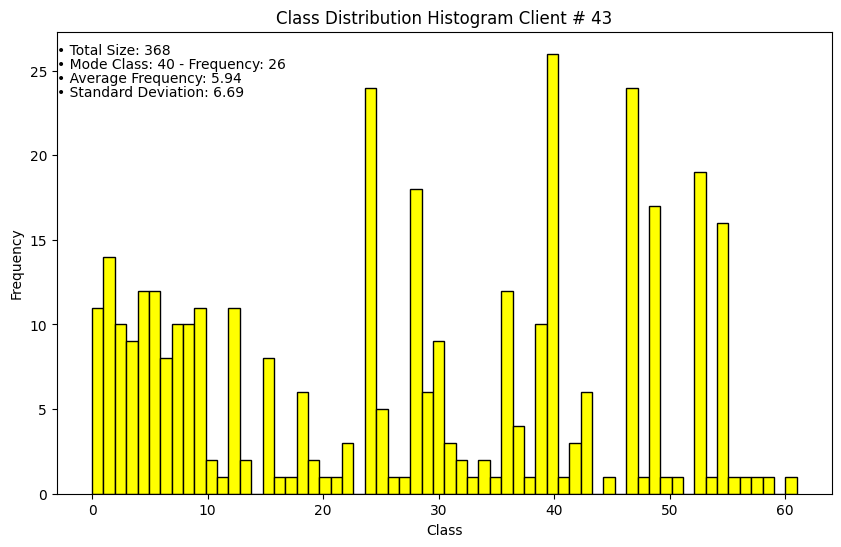

In [38]:
plt.figure(figsize=(10, 6))
labels = train_data_arr[42]['labels']
plt.hist(labels, bins=62, color='yellow', edgecolor='black')

# Calculate statistics
total_size = len(labels)
mode_class = np.bincount(labels).argmax()
mode_frequency = np.bincount(labels).max()
average_frequency = np.mean(np.bincount(labels))
std_dev_frequency = np.std(np.bincount(labels))

# Annotate the plot
plt.title('Class Distribution Histogram Client # 43')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.text(0.0, 0.95, f'\u2022 Total Size: {total_size:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.92, f'\u2022 Mode Class: {mode_class} - Frequency: {mode_frequency:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.89, f'\u2022 Average Frequency: {average_frequency:.2f}', transform=plt.gca().transAxes)
plt.text(0.0, 0.86, f'\u2022 Standard Deviation: {std_dev_frequency:.2f}', transform=plt.gca().transAxes)



plt.show()

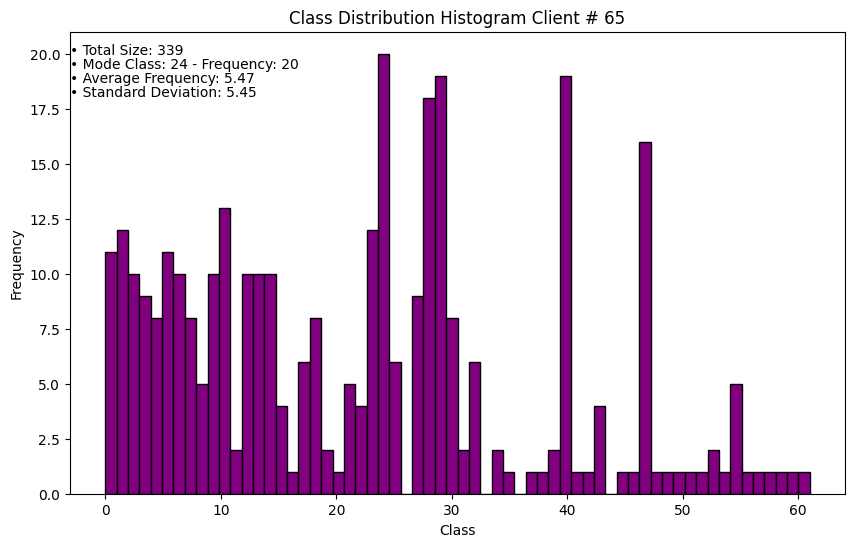

In [42]:
plt.figure(figsize=(10, 6))
labels = train_data_arr[64]['labels']
plt.hist(labels, bins=62, color='purple', edgecolor='black')

# Calculate statistics
total_size = len(labels)
mode_class = np.bincount(labels).argmax()
mode_frequency = np.bincount(labels).max()
average_frequency = np.mean(np.bincount(labels))
std_dev_frequency = np.std(np.bincount(labels))

# Annotate the plot
plt.title('Class Distribution Histogram Client # 65')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.text(0.0, 0.95, f'\u2022 Total Size: {total_size:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.92, f'\u2022 Mode Class: {mode_class} - Frequency: {mode_frequency:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.89, f'\u2022 Average Frequency: {average_frequency:.2f}', transform=plt.gca().transAxes)
plt.text(0.0, 0.86, f'\u2022 Standard Deviation: {std_dev_frequency:.2f}', transform=plt.gca().transAxes)



plt.show()

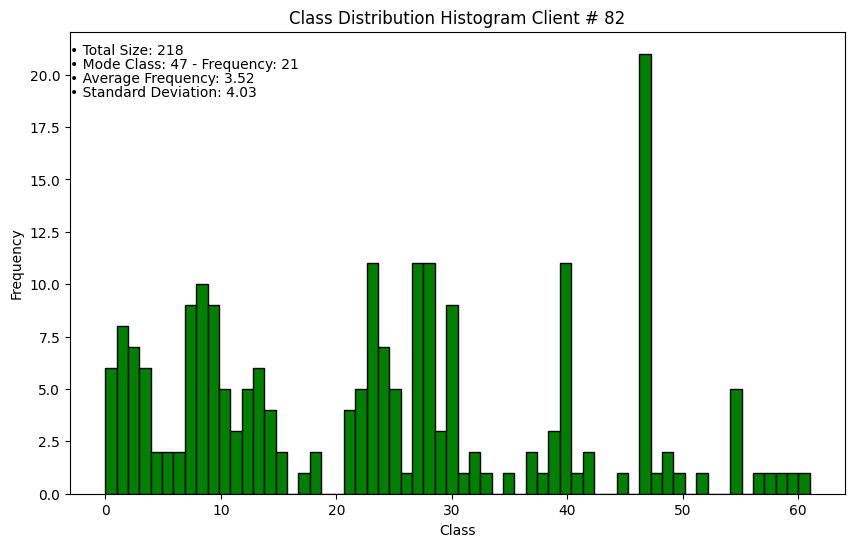

In [43]:
plt.figure(figsize=(10, 6))
labels = train_data_arr[81]['labels']
plt.hist(labels, bins=62, color='green', edgecolor='black')

# Calculate statistics
total_size = len(labels)
mode_class = np.bincount(labels).argmax()
mode_frequency = np.bincount(labels).max()
average_frequency = np.mean(np.bincount(labels))
std_dev_frequency = np.std(np.bincount(labels))

# Annotate the plot
plt.title('Class Distribution Histogram Client # 82')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.text(0.0, 0.95, f'\u2022 Total Size: {total_size:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.92, f'\u2022 Mode Class: {mode_class} - Frequency: {mode_frequency:}', transform=plt.gca().transAxes)
plt.text(0.0, 0.89, f'\u2022 Average Frequency: {average_frequency:.2f}', transform=plt.gca().transAxes)
plt.text(0.0, 0.86, f'\u2022 Standard Deviation: {std_dev_frequency:.2f}', transform=plt.gca().transAxes)



plt.show()